In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [3]:
batch_size = 64

learning_rate = 0.001

epochs = 5

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [5]:
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

100%|██████████| 9.91M/9.91M [00:19<00:00, 505kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 71.7kB/s]
100%|██████████| 1.65M/1.65M [00:04<00:00, 361kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.1MB/s]


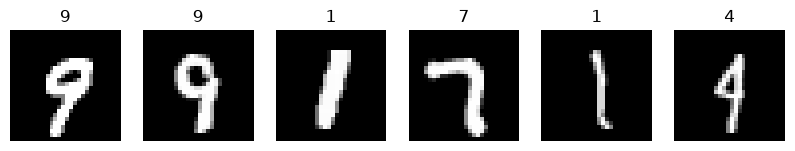

In [6]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 3))

for i in range(6):
    plt.subplot(1, 6, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(labels[i].item())
    plt.axis("off")

plt.show()

In [7]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2)

        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64 * 7 * 7, 128),

            nn.ReLU(),

            nn.Linear(128, 10)

        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [8]:
model = CNN().to(device)

print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate
)

In [10]:
for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )

Epoch [1/5] Loss: 0.1535
Epoch [2/5] Loss: 0.0461
Epoch [3/5] Loss: 0.0330
Epoch [4/5] Loss: 0.0246
Epoch [5/5] Loss: 0.0198


In [11]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 99.11%


In [12]:
torch.save(
    model.state_dict(),
    "cnn_mnist.pth"
)

print("Model Saved Successfully!")
model = CNN().to(device)

model.load_state_dict(torch.load("cnn_mnist.pth", map_location=device))


Model Saved Successfully!


<All keys matched successfully>

In [13]:
images, labels = next(iter(test_loader))

image = images[0].unsqueeze(0).to(device)

label = labels[0]

with torch.no_grad():

    output = model(image)

    _, prediction = torch.max(output, 1)

print("Actual :", label.item())
print("Predicted :", prediction.item())

Actual : 7
Predicted : 7


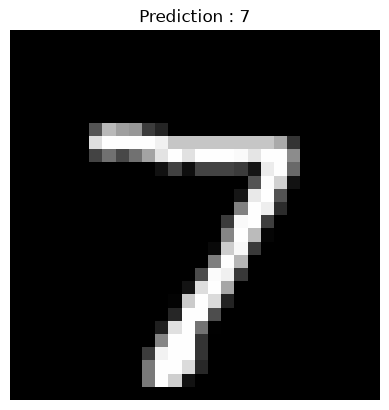

In [14]:
plt.imshow(images[0].squeeze(), cmap="gray")

plt.title(f"Prediction : {prediction.item()}")

plt.axis("off")

plt.show()

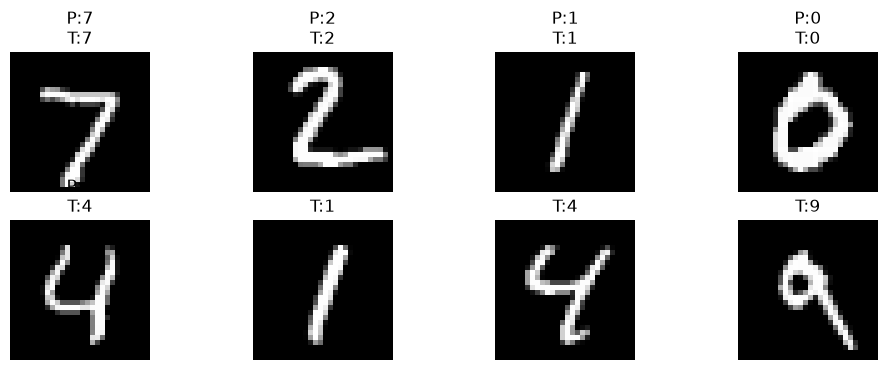

In [15]:
images, labels = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():

    outputs = model(images)

    _, predictions = torch.max(outputs,1)

plt.figure(figsize=(12,4))

for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(images[i].cpu().squeeze(), cmap="gray")

    plt.title(
        f"P:{predictions[i].item()}\nT:{labels[i].item()}"
    )

    plt.axis("off")

plt.show()